# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

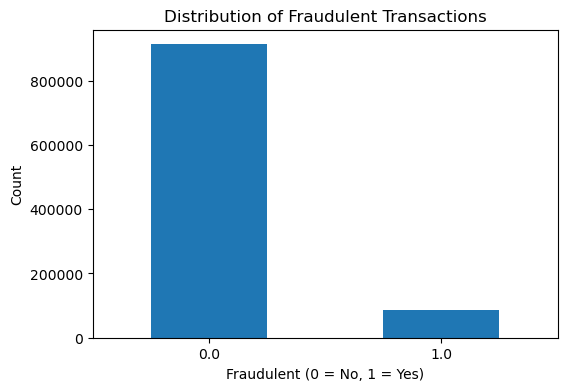

Number of fraudulent transactions: 87403.0
Number of non-fraudulent transactions: 912597.0


In [7]:
# 1. Distribution
fraud["fraud"].value_counts()
fraud["fraud"].value_counts(normalize=True)

# plot the distribution of the target variable
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
fraud["fraud"].value_counts().plot(kind="bar")
plt.title("Distribution of Fraudulent Transactions")
plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
 
print("Number of fraudulent transactions:", fraud["fraud"].sum())
print("Number of non-fraudulent transactions:", len(fraud) - fraud["fraud"].sum())  


In [8]:
# 2. Train baseline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = fraud.drop("fraud", axis=1)
y = fraud["fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [9]:
# 3. Evaluate baseline

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[181293   1226]
 [  6914  10567]]
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98    182519
         1.0       0.90      0.60      0.72     17481

    accuracy                           0.96    200000
   macro avg       0.93      0.80      0.85    200000
weighted avg       0.96      0.96      0.96    200000

ROC-AUC: 0.967026437409886


In [11]:
# 4. Oversample data

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_train_over, y_train_over)

y_pred_over = model_over.predict(X_test)
y_prob_over = model_over.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_over))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_over))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC: 0.9795245778974815


In [12]:
# 5. Undersample data

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_train_under, y_train_under)

y_pred_under = model_under.predict(X_test)
y_prob_under = model_under.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_under))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_under))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC: 0.9795769787728351


In [13]:
# 6. SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
y_prob_smote = model_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.94    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.94      0.94    200000

ROC-AUC: 0.9791806576425602


**Insight**

**We are dealing with an imbalanced dataset**

- Fraud represents only ~9% of transactions → highly imbalanced dataset
- Model trained on raw data is biased toward non-fraud cases
- Accuracy alone is misleading in this context

**Baseline Model (Logistic Regression)**

- High accuracy (**96%**) but:
- Fraud detection is weak → recall only **60%**
- Model misses ~40% of fraud cases → high business risk 
- ROC-AUC already strong (**0.97**) → model has good underlying signal

**Oversampling**

- Fraud recall jumps from **60% → 95%** 
- Model becomes much better at detecting fraud
- Trade-off: precision drops (**90% → 58%**) → more false positives
- Accuracy slightly decreases (**96% → 93%**) but model is more useful

**Undersampling**

- Similar performance to oversampling
- But removes a large amount of data → less efficient
- No real advantage over oversampling in this case

**SMOTE**

- Performs similarly to oversampling
- Slightly more stable and realistic (synthetic data vs duplication)
- Keeps high recall (~95%) while maintaining strong ROC-AUC (~0.98)

**Final Takeaway**

- In fraud detection → **recall matters more than accuracy**
- Missing fraud = direct financial loss
- Best approach:
  → Use SMOTE or Oversampling  
  → Optimize for recall + ROC-AUC  
  → Accept more false positives as a trade-off